# Praktikum PSD Semester 4

- Nama: Raka Muhammad Al Hafidz
- Kelas: 2C_TNK
- NIM: 241344087

## Peak Detection, Trough Detection, and Zero Crossing

In [1]:
# Peak Detection: Deteksi titik puncak dari sinyal
# Trough Detection: Deteksi titik lembah dari sinyal
# Zero Crossing: Mendeteksi sinyal ketika melewati titik tengah/titik nol.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.io import wavfile

In [3]:
fs = 1000
f = 3
A = 1
phase = 0
dur = 1

t = np.linspace(0, dur, int(fs * dur), endpoint=False)
signal_sine = A * np.sin(2 * np.pi * f * t + np.deg2rad(phase))

In [ ]:

#Deteksi titik puncak
peaks_id, peaks_properties = find_peaks(signal_sine, height=0.5)
peak_times = t[peaks_id]
peaks_values = signal_sine[peaks_id]

#Deteksi titik lembah
troughs_id, troughs_properties = find_peaks(-signal_sine, height=-0.5)
trough_times = t[troughs_id]
troughs_values = signal_sine[troughs_id]

## Minus maksudnya untuk membalik sinyal sehingga titik lembah menjadi puncak, sehingga bisa dideteksi dengan find_peaks.
## Height digunakan untuk menentukan ambang batas deteksi, dalam hal ini hanya mendeteksi puncak yang lebih
# tinggi dari 0.5 dan lembah yang lebih rendah dari -0.5.

#Deteksi zero crossing
zero_crossing = np.where(np.diff(np.sign(signal_sine)))[0]
zero_crossing_times = t[zero_crossing]

Julah puncak: 3
Julah lembah: 3
Julah zero crossings: 6


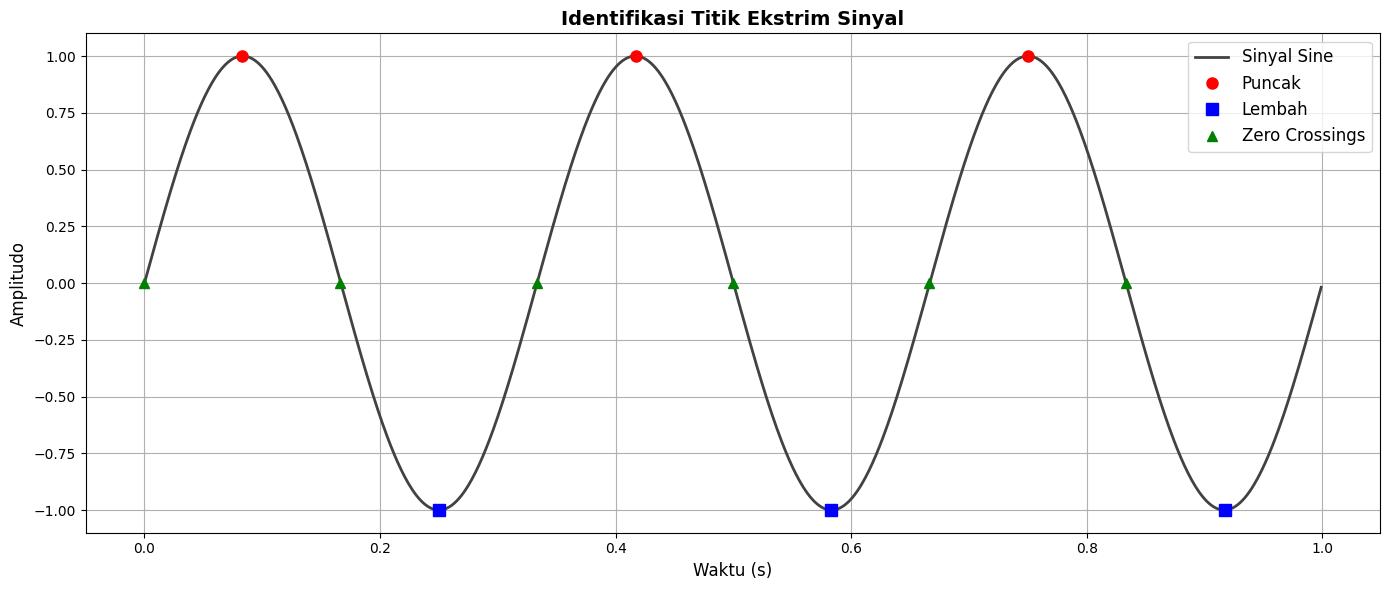

In [55]:
print(f'Julah puncak: {len(peaks_id)}')
print(f'Julah lembah: {len(troughs_id)}')
print(f'Julah zero crossings: {len(zero_crossing)}')

plt.figure(figsize=(14, 6))
plt.plot(t, signal_sine, linewidth=2, color="#424242", label='Sinyal Sine') # Sinyal asli
plt.plot(peak_times, peaks_values, 'ro', markersize=8, label='Puncak') # Marker puncak
plt.plot(trough_times, troughs_values, 'bs', markersize=8, label='Lembah') # Marker lembah
plt.plot(zero_crossing_times, np.zeros_like(zero_crossing_times), 'g^', markersize=7, label='Zero Crossings') # Marker zero crossing
plt.xlabel('Waktu (s)', fontsize=12)
plt.ylabel('Amplitudo', fontsize=12)
plt.title('Identifikasi Titik Ekstrim Sinyal', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
# Sampling -> Detik:
# sample/fs = detik

/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_29704/862950130.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_wav, signal_from_wav = wavfile.read('mic1.wav')


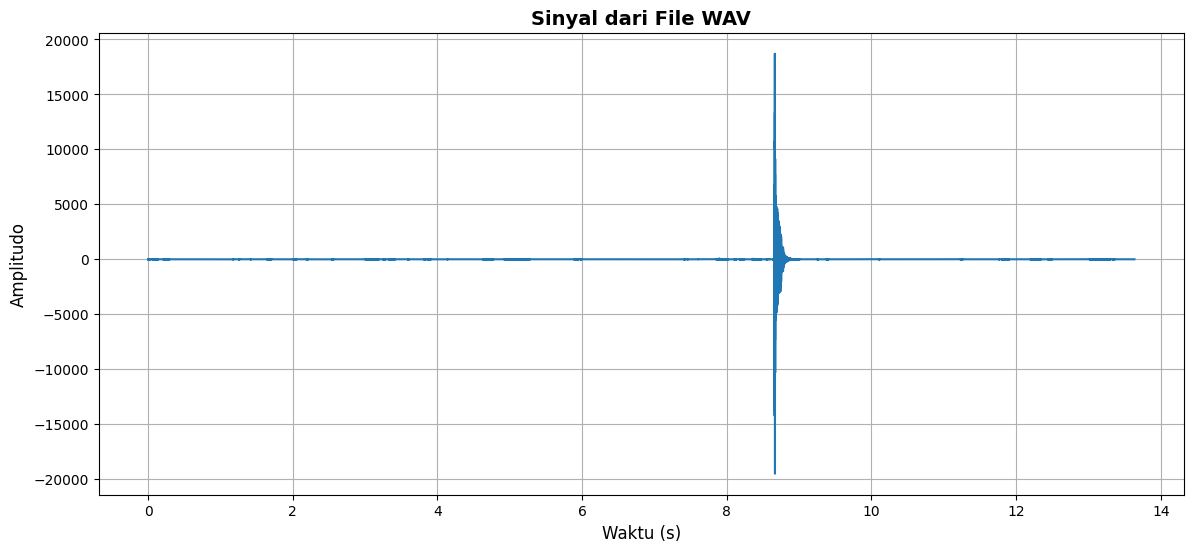

In [ ]:
fs_wav, signal_from_wav = wavfile.read('mic1.wav')
signal_from_wav = signal_from_wav.astype(np.float32) #besar bitsize Bergantung dari device/mikrofon

#Sumbu x
time_vector = np.arange(0, len(signal_from_wav))/fs_wav # Sumbu x

plt.figure(figsize=(14, 6))
plt.plot(time_vector, signal_from_wav)
plt.xlabel('Waktu (s)', fontsize=12)
plt.ylabel('Amplitudo', fontsize=12)
plt.title('Sinyal dari File WAV', fontsize=14, fontweight='bold')
plt.grid()
plt.show()

Julah puncak: 173563
Julah lembah: 238909
Julah zero crossings: 407634


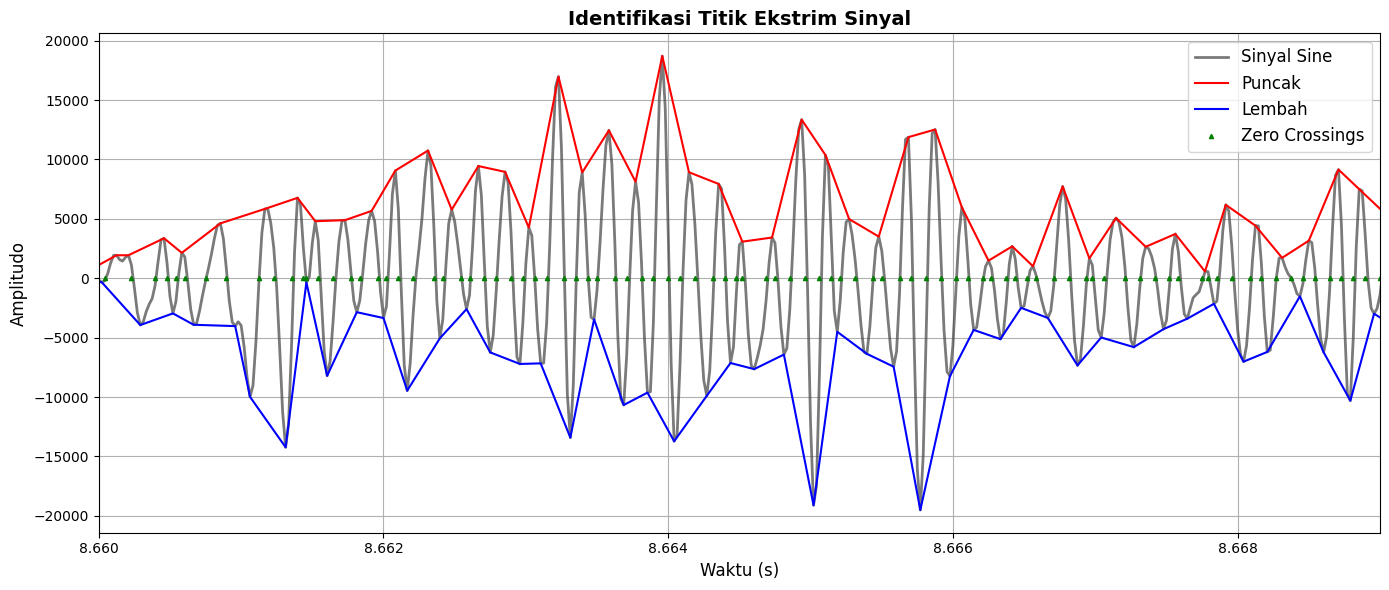

In [66]:
signal_sine = signal_from_wav
t = time_vector

#Deteksi titik puncak
peaks_id, peaks_properties = find_peaks(signal_sine, height=0.5)
peak_times = t[peaks_id]
peaks_values = signal_sine[peaks_id]

#Deteksi titik lembah
troughs_id, troughs_properties = find_peaks(-signal_sine, height=-0.5)
trough_times = t[troughs_id]
troughs_values = signal_sine[troughs_id]


## Minus maksudnya untuk membalik sinyal sehingga titik lembah menjadi puncak, sehingga bisa dideteksi dengan find_peaks.
## Height digunakan untuk menentukan ambang batas deteksi, dalam hal ini hanya mendeteksi puncak yang lebih tinggi dari 0.5 dan lembah yang lebih rendah dari -0.5.

#Deteksi zero crossing
zero_crossing = np.where(np.diff(np.sign(signal_sine)))[0]
zero_crossing_times = t[zero_crossing]

print(f'Julah puncak: {len(peaks_id)}')
print(f'Julah lembah: {len(troughs_id)}')
print(f'Julah zero crossings: {len(zero_crossing)}')

plt.figure(figsize=(14, 6))
plt.plot(t, signal_sine, linewidth=2, color="#424242B3", label='Sinyal Sine') # Sinyal asli
plt.plot(peak_times, peaks_values, 'r-', markersize=4, label='Puncak') # Marker puncak | 'ro' > marker color = red, markertype = o/circle
plt.plot(trough_times, troughs_values, 'b-', markersize=4, label='Lembah') # Marker lembah | 'bs' > marker color = blue, markertype = s/square
plt.plot(zero_crossing_times, np.zeros_like(zero_crossing_times), 'g^', markersize=3, label='Zero Crossings') # Marker zero crossing | 'g^' > marker color = green, markertype = ^/triangle up
#Untuk menjadikan signal envelope, berikan garis didekat warna: 'r-'
plt.xlabel('Waktu (s)', fontsize=12)
plt.ylabel('Amplitudo', fontsize=12)
plt.xlim([8.66, 8.669])
plt.title('Identifikasi Titik Ekstrim Sinyal', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.grid()
plt.show()

## Normalisasi 

In [24]:
# Mengubah amplitudo
# Menskala kan ulang sinyal

# Normalisasi minmax: menskalakan 0 sampai 1.
# Simetris: 1 sampai -1
# Z Score: Rata rata batas deviasi

# Dipakai untuk machine learning, jadi sinyal nya dikecilkan dari rentang 0 sampai 1, baru dilakukan proses filtering dsb nya.

def normalize_signal(signal, method='minimax', target_range=(0, 1)):
   if method == 'minimax':
      min_val = np.min(signal)
      max_val = np.max(signal)
      normalized_signal = (signal - min_val) / (max_val - min_val)
      normalized_signal = normalized_signal * (target_range[1] - target_range[0]) + target_range[0]
   elif method == 'symmetric':
      signal_abs_max = np.max(np.abs(signal))
      normalized_signal = signal / signal_abs_max
   elif method == 'zscore':
      mean = np.mean(signal)
      std = np.std(signal)
      normalized_signal = (signal - mean) / std
   else:
      raise ValueError("method must be 'minimax', 'symmetric', or 'zscore'")

   return normalized_signal

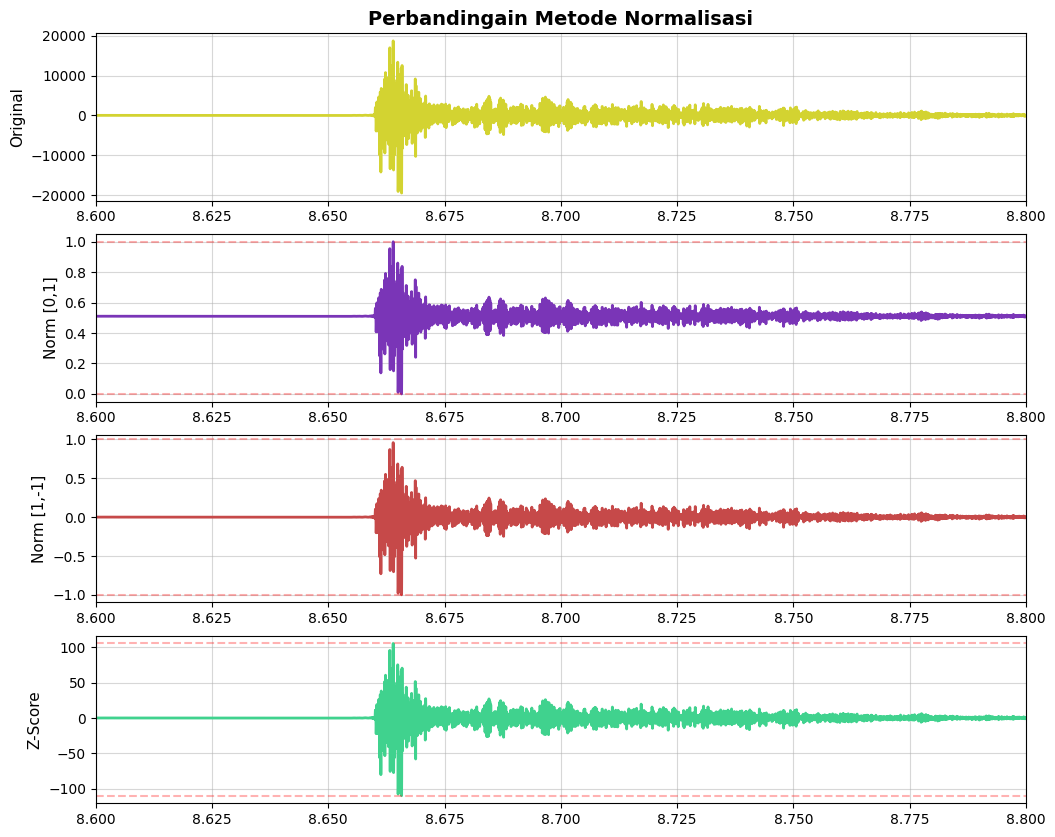

In [ ]:
n_signal_minmax = normalize_signal(signal_from_wav, method='minimax')
n_signal_symmetric = normalize_signal(signal_from_wav, method='symmetric')
n_signal_zscore = normalize_signal(signal_from_wav, method='zscore')

fig, axs = plt.subplots(4, 1, figsize=(12, 10))

axs[0].plot(t, signal_sine, linewidth=2, color="#D3D331")
axs[0].set_ylabel('Original', fontsize=11)
axs[0].set_title('Perbandingain Metode Normalisasi', fontsize=14, fontweight='bold')
axs[0].set_xlim([8.60, 8.80])
axs[0].grid(True, alpha = 0.5)

axs[1].plot(t, n_signal_minmax, linewidth=2, color="#7A35B7")
axs[1].set_ylabel('Norm [0,1]', fontsize=11)
axs[1].axhline(y = 0, color = 'red', linestyle = '--', alpha = .3)
axs[1].axhline(y = 1, color = 'red', linestyle = '--', alpha = .3)
axs[1].set_xlim([8.60, 8.80])
axs[1].grid(True, alpha = 0.5)

axs[2].plot(t, n_signal_symmetric, linewidth=2, color="#C64949")
axs[2].set_ylabel('Norm [1,-1]', fontsize=11)
axs[2].axhline(y = -1, color = 'red', linestyle = '--', alpha = .3)
axs[2].axhline(y = 1, color = 'red', linestyle = '--', alpha = .3)
axs[2].set_xlim([8.60, 8.80])
axs[2].grid(True, alpha = 0.5)

axs[3].plot(t, n_signal_zscore, linewidth=2, color="#40D28E")
axs[3].set_ylabel('Z-Score', fontsize=11)
axs[3].axhline(y = np.max(n_signal_zscore), color = 'red', linestyle = '--', alpha = .3)
axs[3].axhline(y = np.min(n_signal_zscore), color = 'red', linestyle = '--', alpha = .3)
axs[3].set_xlim([8.60, 8.80])
axs[3].grid(True, alpha = 0.5)

### Tugas Praktikum 2
Dari sinyal gabungan mic1.wav, mic2.wav, mic3.wav, mic4.wav. Untuk setiap 25ms dari durasi detik ke-4 sampai dengan detik ke-10. Hitung:

- Jumlah zero-crossing
- Jumlah puncak & Lembah
- Nilai puncak tertinggi
- Rata-rata nilai puncak
- Selisih rata-rata puncak dan lembah

Yang dikumpulkan adalah spreadsheet, dan jupyter notebook (.ipynb)


In [4]:
## IGNORE IF NOT NEEEDED
%cd ../pertemuanpertama/

/Users/raka/Materi Kuliah/PSD 2/pertemuanpertama


In [43]:
# Menggabungkan semua mic.wav:
# Load semua mic.wav nya:

fs_mic1wav, mic1_signalwav = wavfile.read('mic1.wav')
mic1_signalwav = mic1_signalwav.astype(np.float32)

fs_mic2wav, mic2_signalwav = wavfile.read('mic2.wav')
mic2_signalwav = mic2_signalwav.astype(np.float32)

fs_mic3wav, mic3_signalwav = wavfile.read('mic3.wav')
mic3_signalwav = mic3_signalwav.astype(np.float32)

fs_mic4wav, mic4_signalwav = wavfile.read('mic4.wav')
mic4_signalwav = mic4_signalwav.astype(np.float32)

signal_gabungan = mic1_signalwav + mic2_signalwav + mic3_signalwav + mic4_signalwav
dur = len(signal_gabungan) / fs_mic1wav
t_gabungan = np.linspace(0, dur, len(signal_gabungan), endpoint=False)

/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_25369/1139978235.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic1wav, mic1_signalwav = wavfile.read('mic1.wav')
/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_25369/1139978235.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic2wav, mic2_signalwav = wavfile.read('mic2.wav')
/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_25369/1139978235.py:10: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic3wav, mic3_signalwav = wavfile.read('mic3.wav')
/var/folders/lq/l4sbfyv90lx9h4m4_gq3q4n80000gn/T/ipykernel_25369/1139978235.py:13: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_mic4wav, mic4_signalwav = wavfile.read('mic4.wav')


In [44]:
# Pisahkan sinyal dari detik ke 4 sampai 11 detik

signal_gabungan = signal_gabungan[int(4*fs_mic1wav):int(10*fs_mic1wav)]
t_gabungan = t_gabungan[int(4*fs_mic1wav):int(10*fs_mic1wav)]

# Deteksi titik puncak, lembah dan zero crossing pada sinyal gabungan
peaks_id, _ = find_peaks(signal_gabungan)
peak_times = t_gabungan[peaks_id]
peaks_values = signal_gabungan[peaks_id]

troughs_id, _ = find_peaks(-signal_gabungan)
trough_times = t_gabungan[troughs_id]
troughs_values = signal_gabungan[troughs_id]

zero_crossing = np.where(np.diff(np.sign(signal_gabungan)))[0]
zero_crossing_times = t_gabungan[zero_crossing]

print(f'Total Jumlah puncak (4-10 detik): {len(peaks_id)}')
print(f'Total Jumlah lembah (4-10 detik): {len(troughs_id)}')
print(f'Total Jumlah zero crossings (4-10 detik): {len(zero_crossing)}')


Total Jumlah puncak (4-10 detik): 77014
Total Jumlah lembah (4-10 detik): 77014
Total Jumlah zero crossings (4-10 detik): 32254


Note: Total jumlah yang ada di atas bakal berbeda dengan yang ada pada spreadsheet. Karena menghitung langsung dari awal sampai akhir, berbeda dengan menghitung per 25ms. Angkanya sedikit lebih kecil karena peak di tepi potongan "hilang"/rada tidak tertangkap.

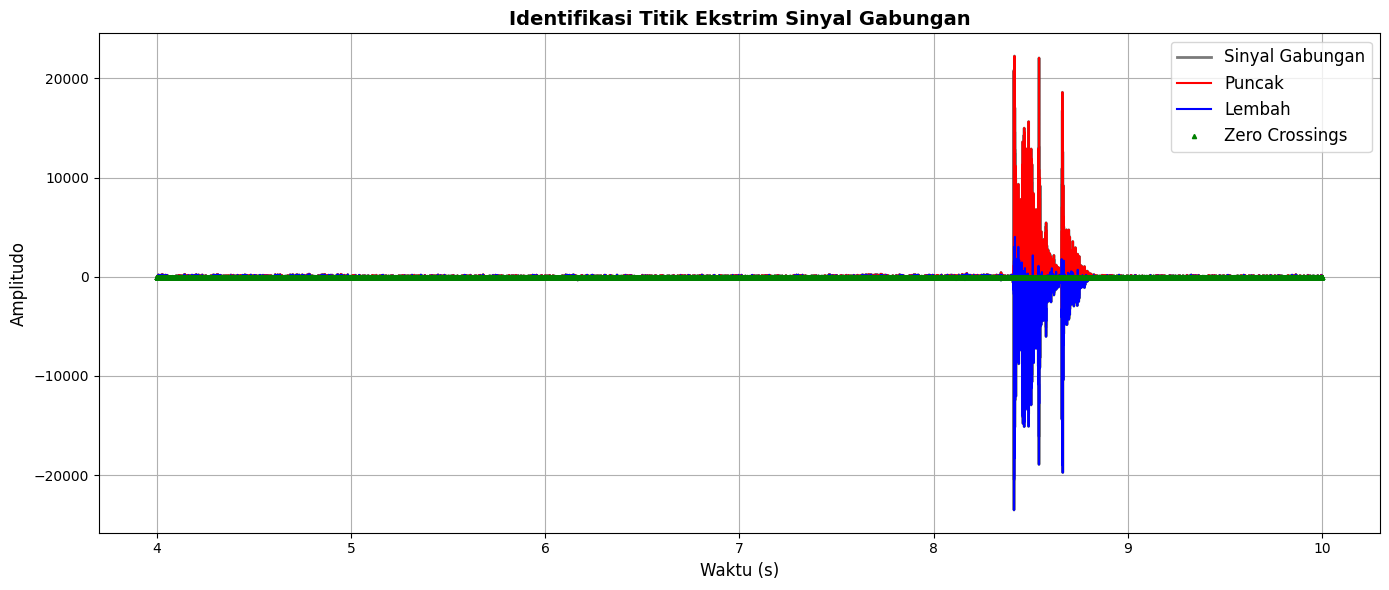

In [45]:
#Ploting sinyal gabungan dengan titik puncak, lembah, dan zero crossing
plt.figure(figsize=(14, 6))
plt.plot(t_gabungan, signal_gabungan, linewidth=2, color="#424242B3", label='Sinyal Gabungan') # Sinyal gabungan
plt.plot(peak_times, peaks_values, 'r-', markersize=4, label='Puncak') # Marker puncak | 'ro' > marker color = red, markertype = o/circle
plt.plot(trough_times, troughs_values, 'b-', markersize=4, label='Lembah') # Marker lembah | 'bs' > marker color = blue, markertype = s/square
plt.plot(zero_crossing_times, np.zeros_like(zero_crossing_times), 'g^', markersize=3, label='Zero Crossings') # Marker zero crossing | 'g^' > marker color = green, markertype = ^/triangle up
plt.xlabel('Waktu (s)', fontsize=12)
plt.ylabel('Amplitudo', fontsize=12)
plt.title('Identifikasi Titik Ekstrim Sinyal Gabungan', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.grid()
plt.show()

Sinyal `y` di-normalize sehingga yang keluar bukan 'sample'. Jadi bisa lebih terbaca

In [47]:

# Ambil untuk tiap 25ms dari detik 4 sampai 10 detik

segment_data = []
step_size = int(0.025 * fs_mic1wav)

for i in range(0, len(signal_gabungan), step_size):
    segment = signal_gabungan[i:i + step_size]

    if len(segment) == 0:
        continue

    start_time = t_gabungan[i]
    end_time = start_time + 0.025

    peaks_id, _ = find_peaks(segment)
    troughs_id, _ = find_peaks(-segment)
    zero_crossing = np.where(np.diff(np.sign(segment)))[0]

    peaks_values_seg = segment[peaks_id]
    troughs_values_seg = segment[troughs_id]

    nilai_puncak_tertinggi = np.max(peaks_values_seg)
    rata_rata_puncak = np.mean(peaks_values_seg)
    rata_rata_lembah = np.mean(troughs_values_seg)
    selisih_rata_puncak_lembah = rata_rata_puncak - rata_rata_lembah

    segment_data.append({
        'time': f'{start_time:.3f}-{end_time:.3f} s',
        'total_peaks': len(peaks_id),
        'total_troughs': len(troughs_id),
        'total_zero_crossings': len(zero_crossing),
        'nilai_puncak_tertinggi': nilai_puncak_tertinggi,
        'rata_rata_puncak': rata_rata_puncak,
        'selisih_rata_puncak_lembah': selisih_rata_puncak_lembah
    })


In [48]:
# Export to Excel:

with pd.ExcelWriter('segmen_data_tugas_2.xlsx') as writer:
   df_sinyal_gabungan = pd.DataFrame(segment_data)
   total_row = {
      'time': 'TOTAL',
      'total_peaks': df_sinyal_gabungan['total_peaks'].sum(),
      'total_troughs': df_sinyal_gabungan['total_troughs'].sum(),
      'total_zero_crossings': df_sinyal_gabungan['total_zero_crossings'].sum()
   }
   df_total_rows = pd.DataFrame(total_row, index=[0])
   df_sinyal_gabungan = pd.concat(
      [df_sinyal_gabungan, df_total_rows],
      ignore_index=True
   )
   df_sinyal_gabungan.to_excel(writer, sheet_name='Segment Data', index=False)

## Timestamp Marking

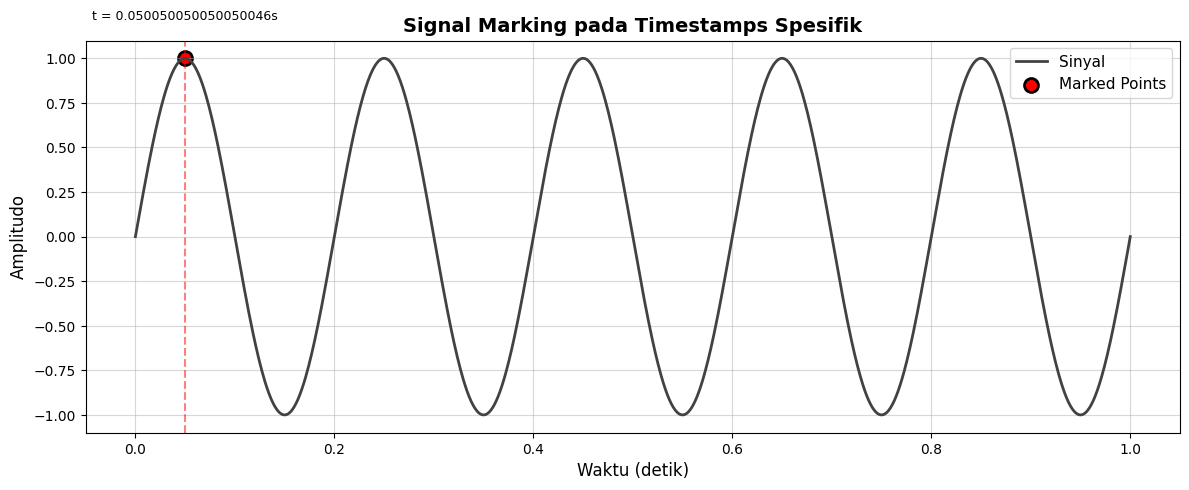

In [9]:
# Tujuannya -> Menandai timestamp dimana menjadi point of interest
# Point of interest = Bisa titik ekstrem, titik lembah, titik tengah, titik puncak dimana.

# Untuk mencari nilai Y nya berdasarkan input x nya:
def mark_timestamps(signal, time_vector, timestamps):

   marked_indices = []
   marked_values = []

   for ts in timestamps:
      idx = np.argmin(np.abs(time_vector - ts))
      marked_indices.append(idx)
      marked_values.append(signal[idx])

   #return nya adalah baris array yang berisi index dan nilai yang sudah ditandai
   return np.array(marked_indices), np.array(marked_values)

# timestamps_to_mark = [0.1, 0.3, 0.5, 0.7, 0.9] # hasil dari proses / fungsi lain
timestamps_to_mark = [t[np.argmax(signal_sine)]]

#Buat sinyal baru:
fs = 1000
f = 5
dur = 1

t = np.linspace(0, dur, int(fs * dur))
signal_sine = np.sin(2 * np.pi * f * t)

mark_idx, mark_values = mark_timestamps(signal_sine, t, timestamps_to_mark)
#mark_idx = sumbu x
#mark_values = sumbu y

# ====== Visualisasi ======

plt.figure(figsize=(12, 5))
plt.plot(t, signal_sine, linewidth = 2, color = "#424242", label='Sinyal')
plt.scatter(t[mark_idx], mark_values, color='red', s = 100, marker = 'o', edgecolors = 'black', linewidths= 2, label='Marked Points',)

#scatter = bentuk ploting lain untuk plotting dengan plt.scatter()

for i, ts in enumerate (timestamps_to_mark):
   plt.axvline(x = ts, color='red', linestyle = '--', alpha= 0.5)
   plt.text(ts, mark_values[i] + 0.2, f't = {ts}s', fontsize=9, ha='center', va='bottom')


plt.xlabel('Waktu (detik)', fontsize = 12)
plt.ylabel('Amplitudo', fontsize = 12)
plt.title('Signal Marking pada Timestamps Spesifik', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha = 0.5)
plt.tight_layout()
plt.show()


## Padding & Trimming

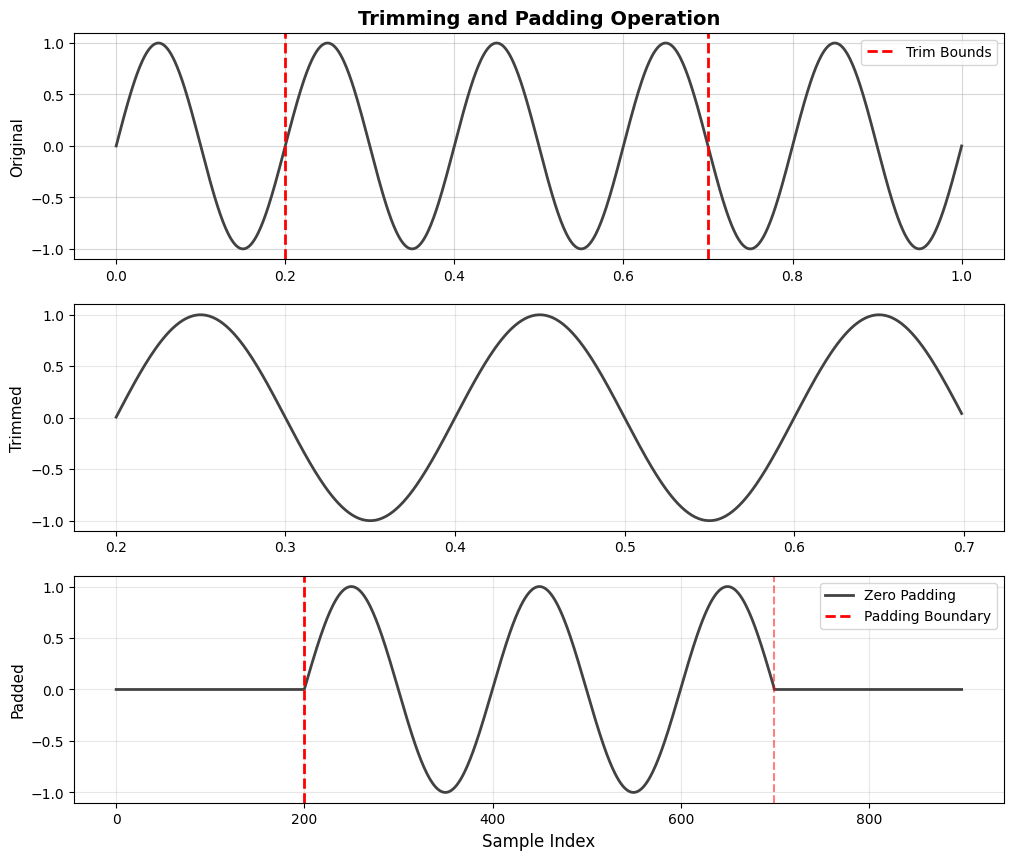

In [ ]:
# ---- Trimming -----

def trim_signal(signal, time_vector, start_time, end_time):
   start_idx = np.argmin(np.abs(time_vector - start_time))
   end_idx = np.argmin(np.abs(time_vector - end_time))

   trimmed_signal = signal[start_idx:end_idx]
   trimmed_time_vector = time_vector[start_idx:end_idx]


   return trimmed_signal, trimmed_time_vector

signal_trimmed, t_trimmed = trim_signal(signal_sine, t, 0.2, 0.7)

# ---- Padding Function ----

def pad_signal(signal, pad_length, mode = 'zero', position = 'both'):
   if mode == 'zero':
      pad_value = 0
   elif mode == 'edge':
      pad_value = None

   if position == 'both':
      if mode == 'zero':
         padded_signal = np.pad(signal, pad_length, mode='constant', constant_values=pad_value)
      else:
         padded_signal = np.pad(signal, pad_length, mode=mode)
   elif position == 'start':
      if mode == 'zero':
         padded_signal = np.pad(signal, (pad_length, 0), mode='constant', constant_values=pad_value)
      else:
         padded_signal = np.pad(signal, (pad_length, 0), mode=mode)
   elif position == 'end':
      if mode == 'zero':
         padded_signal = np.pad(signal, (0, pad_length), mode='constant', constant_values=pad_value)
      else:
         padded_signal = np.pad(signal, (0, pad_length), mode=mode)
   else:
      raise ValueError("position must be 'both', 'start', or 'end'")

   return padded_signal

pad_len = 200++
pad_time = 200/fs

#Zero: yang dipadding akan diisi dengan nilai 0
signal_padded_zero = pad_signal(signal_trimmed, pad_len, mode='zero')
#Edge: yang dipadding akan diisi dengan nilai dari edge (nilai paling awal dan paling akhir dari sinyal yang sudah di trim)
signal_padded_edge = pad_signal(signal_sine, pad_len, mode='edge', position='both')

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t, signal_sine, linewidth=2, color="#424242")
axes[0].axvline(x = 0.2, color='red', linestyle = '--', linewidth = 2, label='Trim Bounds')
axes[0].axvline(x = 0.7, color='red', linestyle = '--', linewidth = 2)
axes[0].set_ylabel('Original', fontsize=11)
axes[0].set_title('Trimming and Padding Operation', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha = 0.5)

axes[1].plot(t_trimmed, signal_trimmed, linewidth=2, color="#424242")
axes[1].set_ylabel('Trimmed', fontsize=11)
axes[1].grid(True, alpha = 0.3)

axes[2].plot(signal_padded_zero, linewidth=2, color="#424242", label='Zero Padding')
axes[2].axvline(x = pad_len, color='red', linestyle = '--', linewidth = 2, label='Padding Boundary')
axes[2].axvline(x = len(signal_trimmed) + pad_len, color='red', linestyle = '--', alpha = 0.5)
axes[2].set_ylabel('Padded', fontsize=11)
axes[2].set_xlabel('Sample Index', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha = 0.3)



## Amplifying, Delay

## Random Signal & Noise

## Time Domain Filter